In [13]:
#importing librarires
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [14]:
#reading the dataset
data = pd.read_csv('D:\project\diabetes_012_health_indicators_BRFSS2015.csv')
data

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [15]:
#removing unnecessary columnns
data = data.drop(['Education','Fruits','Veggies','Sex','Income'],axis=1)


In [16]:
#Separate Features and Target
X = data.drop('Diabetes_012', axis=1)
Y = data['Diabetes_012']



In [17]:
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Age
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,9.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,7.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,9.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,11.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0,5.0
253676,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,11.0
253677,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0
253678,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,7.0


In [18]:
X.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump',
       'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth',
       'DiffWalk', 'Age'],
      dtype='object')

In [19]:
Y

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    2.0
253677    0.0
253678    0.0
253679    2.0
Name: Diabetes_012, Length: 253680, dtype: float64

In [20]:
# Split: 80% Training, 20% Testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


In [21]:
# 3. Initialize and apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)
# 4. Check the results
print(f"Before SMOTE: {Y_train.value_counts()}")
print(f"After SMOTE: {Y_train_balanced.value_counts()}")


Before SMOTE: Diabetes_012
0.0    170962
2.0     28277
1.0      3705
Name: count, dtype: int64
After SMOTE: Diabetes_012
0.0    170962
2.0    170962
1.0    170962
Name: count, dtype: int64


In [23]:
#logisticregresssion
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train_balanced,Y_train_balanced)
#prediction
y_pred_log = model_log.predict(X_test)
print("Accuracy :",accuracy_score(Y_test,y_pred_log))
print("confusion matrix:\n",confusion_matrix(Y_test,y_pred_log))
print("classification report:\n",classification_report(Y_test,y_pred_log))

Accuracy : 0.6400189214758751
confusion matrix:
 [[28077  7364  7300]
 [  261   292   373]
 [ 1251  1715  4103]]
classification report:
               precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     42741
         1.0       0.03      0.32      0.06       926
         2.0       0.35      0.58      0.44      7069

    accuracy                           0.64     50736
   macro avg       0.44      0.52      0.42     50736
weighted avg       0.85      0.64      0.72     50736



In [24]:
# 1. Generate the Confusion Matrix data
cm = confusion_matrix(Y_test, y_pred_log)
cm

array([[28077,  7364,  7300],
       [  261,   292,   373],
       [ 1251,  1715,  4103]], dtype=int64)

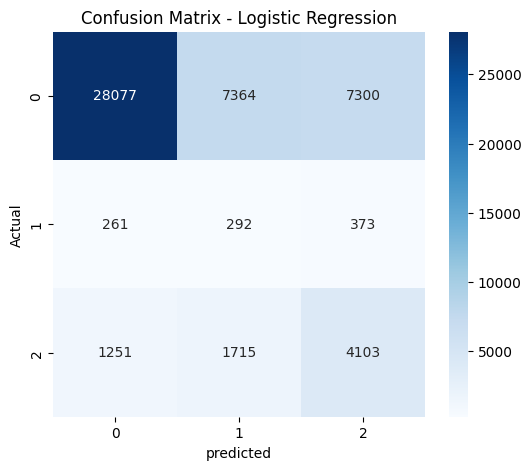

In [25]:
#confusion matrix heatmap
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

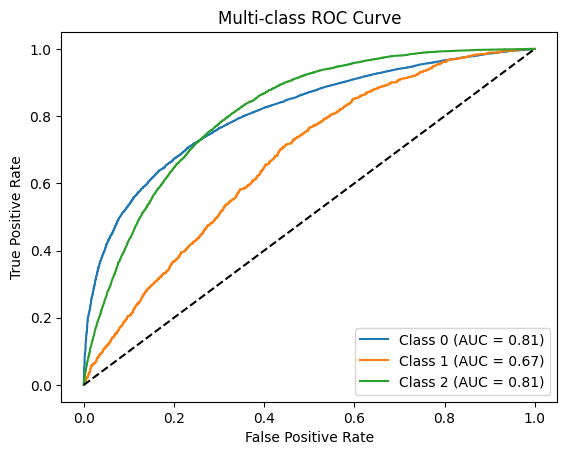

In [26]:
#Multi-Class Roc curve

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize output
y_test_bin = label_binarize(Y_test, classes=[0,1,2])

# Get probabilities
y_prob = model_log.predict_proba(X_test)

plt.figure()

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc(fpr,tpr):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.show()

In [27]:
#decision tree 
model_tree = DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)
model_tree.fit(X_train_balanced,Y_train_balanced)
y_pred_tree=model_tree.predict(X_test)
print("Accuracy :",accuracy_score(Y_test,y_pred_tree))
print("confusion matrix:\n",confusion_matrix(Y_test,y_pred_tree))
print("classification report:\n",classification_report(Y_test,y_pred_tree))

Accuracy : 0.749921160517187
confusion matrix:
 [[33784     0  8957]
 [  500     0   426]
 [ 2805     0  4264]]
classification report:
               precision    recall  f1-score   support

         0.0       0.91      0.79      0.85     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.31      0.60      0.41      7069

    accuracy                           0.75     50736
   macro avg       0.41      0.46      0.42     50736
weighted avg       0.81      0.75      0.77     50736



c:\Users\ANJU\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ANJU\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ANJU\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

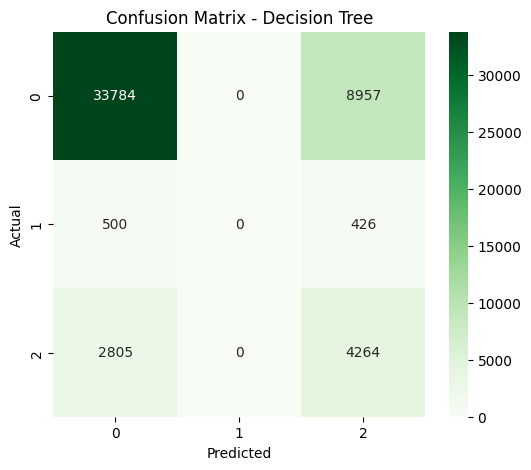

In [28]:
#confusion Matrix heatmap

import seaborn as sns
cm=confusion_matrix(Y_test,y_pred_tree)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

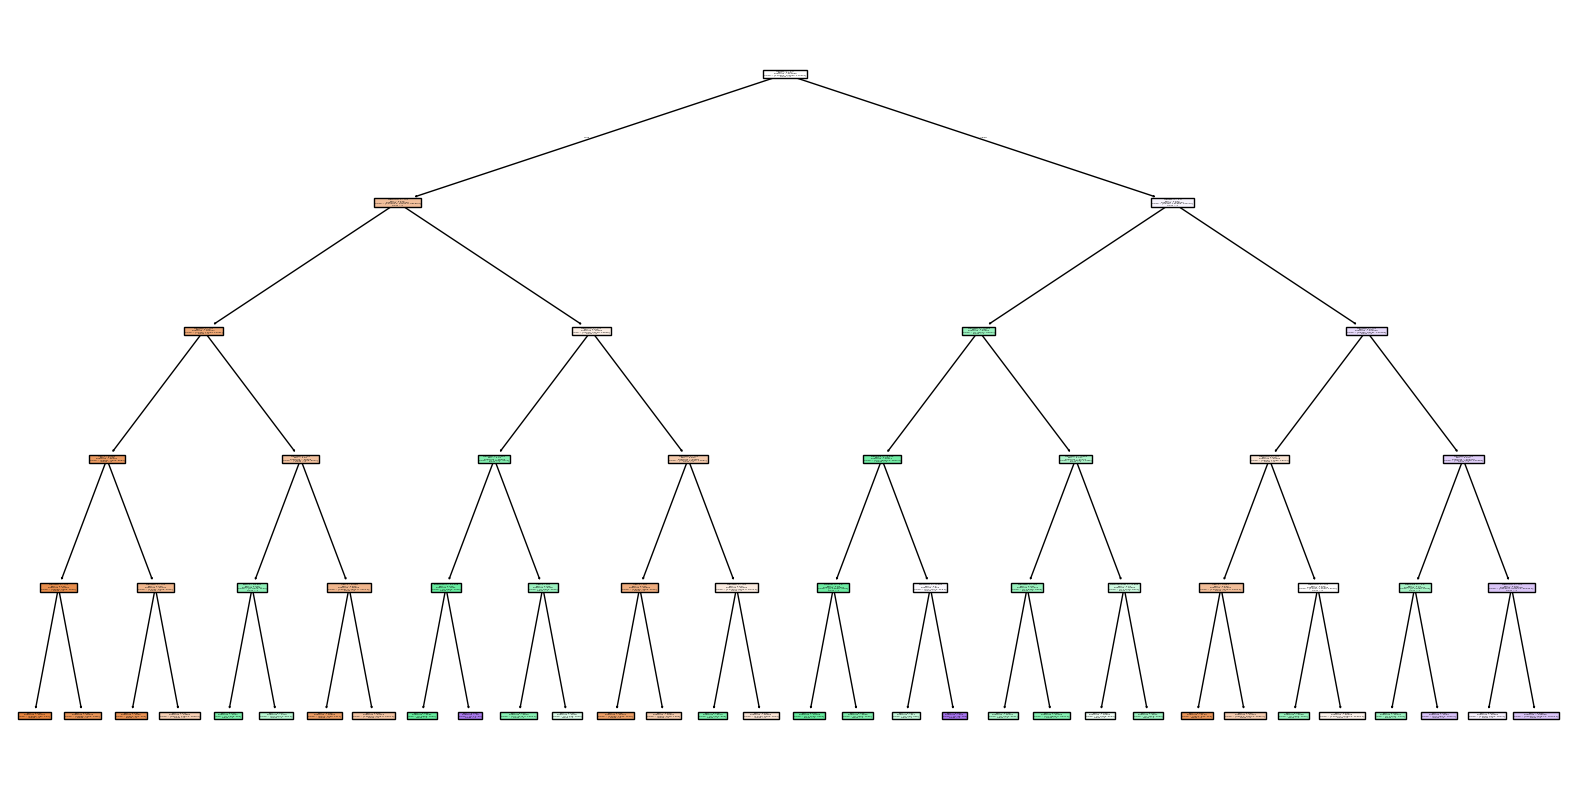

In [29]:
#Decison Tree structure visualization

from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model_tree,
          feature_names=X.columns,
          class_names=['0','1','2'],
          filled=True)
plt.show()

In [30]:
#Training the black box challenger
# Initialize and train the multi-class classifier
model = xgb.XGBClassifier(
 n_estimators=100,
 learning_rate=0.1,
 max_depth=6,
   base_score=0.5,
objective='multi:softprob', # Predicts probability for each of the 3 classes
random_state=42
)

model.fit(X_train_balanced, Y_train_balanced)

,objective,'multi:softprob'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
# Initial Evaluation
y_pred = model.predict(X_test)
print("Accuracy :",accuracy_score(Y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(Y_test,y_pred))
print("classification report:\n",classification_report(Y_test,y_pred))



Accuracy : 0.8081244087038789
confusion matrix:
 [[37434    18  5289]
 [  601     0   325]
 [ 3499     3  3567]]
classification report:
               precision    recall  f1-score   support

         0.0       0.90      0.88      0.89     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.39      0.50      0.44      7069

    accuracy                           0.81     50736
   macro avg       0.43      0.46      0.44     50736
weighted avg       0.81      0.81      0.81     50736



In [32]:
# 1. Generate the Confusion Matrix data
cm = confusion_matrix(Y_test, y_pred)
cm

array([[37434,    18,  5289],
       [  601,     0,   325],
       [ 3499,     3,  3567]], dtype=int64)

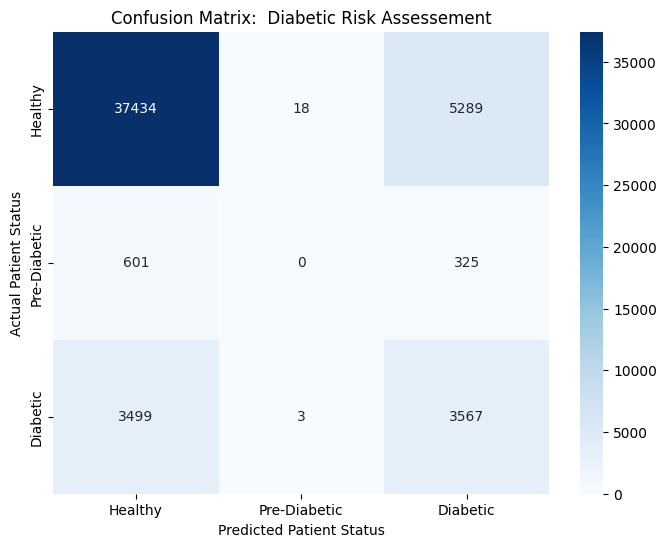

In [33]:
# 2. Create the visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
 xticklabels=['Healthy', 'Pre-Diabetic', 'Diabetic'],
 yticklabels=['Healthy', 'Pre-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix:  Diabetic Risk Assessement')
plt.ylabel('Actual Patient Status')
plt.xlabel('Predicted Patient Status')
plt.show()

PermutationExplainer explainer: 201it [00:37,  5.33it/s]                         
C:\Users\ANJU\AppData\Local\Temp\ipykernel_17352\16495171.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test.iloc[:200, :])


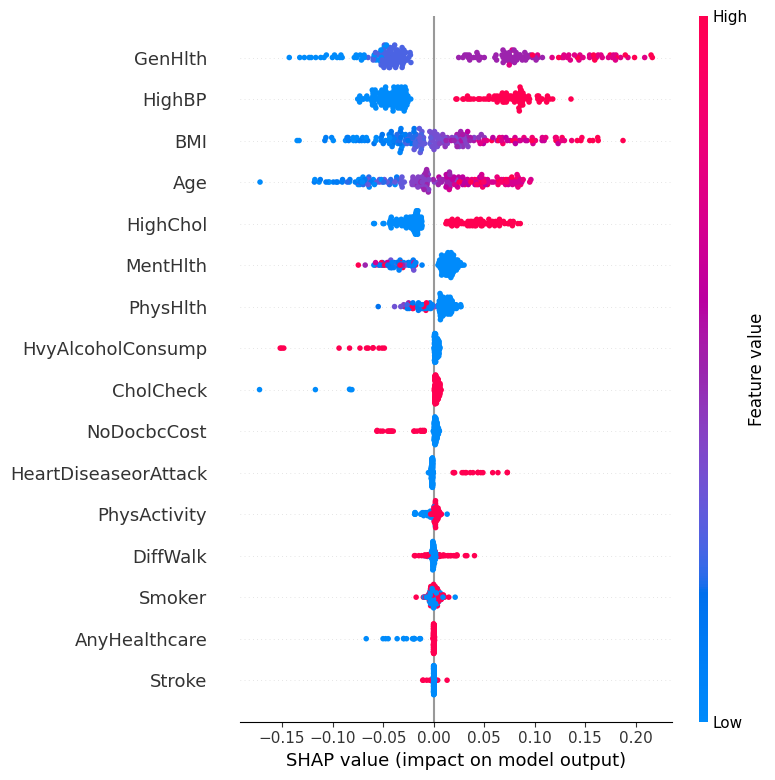

In [34]:
#preparing data for shap
import shap

# 1. Define the probability function for the 'Diabetic' class (Index 2)
def predict_diabetes_prob(x):
    return model.predict_proba(x)[:, 2]

# 2. Use a background sample for speed (First 100 rows of training data)
explainer = shap.Explainer(predict_diabetes_prob, X_train_balanced.iloc[:100, :])

# 3. Calculate SHAP values for a portion of your test set
# We use 200 rows to ensure it runs quickly in VS Code
shap_values = explainer(X_test.iloc[:200, :])

# 4. Plot the results
shap.summary_plot(shap_values, X_test.iloc[:200, :])

--- CLINICAL REPORT ---
Diagnosis: Diabetic
Confidence (Diabetic): 67.83%
------------------------


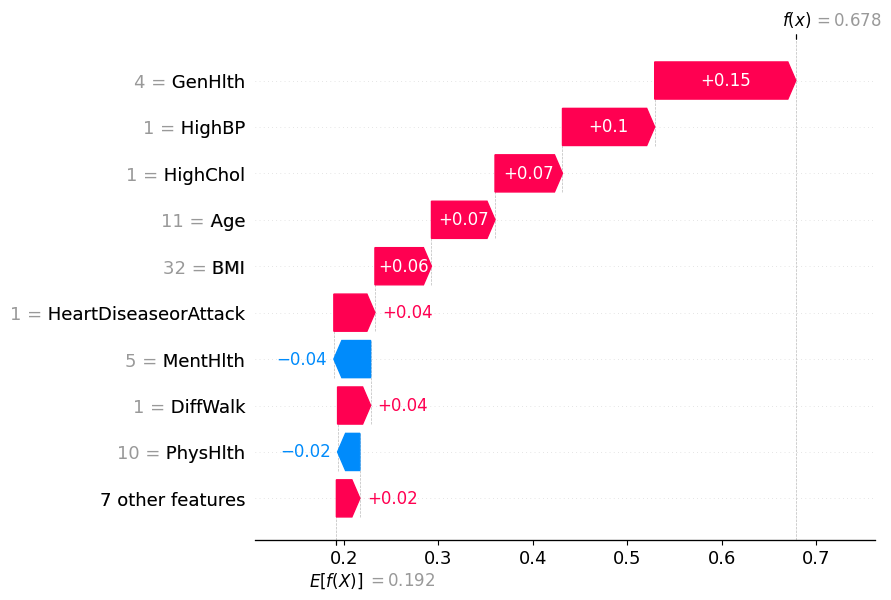

In [35]:
#for a single patients data

def clinical_diagnostic_report(data):
    # 1. Get the Prediction (Class 0, 1, or 2)
    prediction = model.predict(data)[0]
    probs = model.predict_proba(data)[0]
    
    status_map = {0: "Healthy", 1: "Pre-Diabetic", 2: "Diabetic"}
    print(f"--- CLINICAL REPORT ---")
    print(f"Diagnosis: {status_map[prediction]}")
    print(f"Confidence (Diabetic): {probs[2]:.2%}")
    print("------------------------")

    # 2. Generate the Individual Explanation (Waterfall Plot)
    # We use the explainer we created earlier
    patient_shap_values = explainer(data)

    # 3. Plot for the 'Diabetic' class (Index 2)
    plt.figure(figsize=(12, 5))
    shap.plots.waterfall(patient_shap_values[0]) # For Kernel/Explainer objects
    plt.show()

# --- EXAMPLE: Provide data for a NEW person ---
# Ensure these values match the features you kept in your model
new_patient = pd.DataFrame([{
    'HighBP': 1.0, 
    'HighChol': 1.0, 
    'CholCheck': 1.0, 
    'BMI': 32.0, 
    'Smoker': 0.0,
    'Stroke': 0.0, 
    'HeartDiseaseorAttack': 1.0, 
    'PhysActivity': 0.0, 
    'HvyAlcoholConsump':0.0,
    'AnyHealthcare':1.0,
    'NoDocbcCost':0.0,
    'GenHlth': 4.0,
    'MentHlth': 5.0, 
    'PhysHlth': 10.0, 
    'DiffWalk': 1.0, 
    'Age': 11.0
    
}])

clinical_diagnostic_report(new_patient)

In [ ]:
# Counterfactual Explanations: This is a "Gold Standard" for clinical AI.
#  Add a library like DiCE (Diverse Counterfactual Explanations).
# The Pitch: If this patient reduced their BMI from 32 to 27, their risk of diabetes would drop by 15%.
#  This gives the doctor an actionable path.

In [36]:
# Convert all features to float to satisfy XGBoost and DiCE
X_train_balanced = X_train_balanced.astype(float)
X_test = X_test.astype(float)

# Also ensure your 'new_patient' sample is float
new_patient = new_patient.astype(float)

In [40]:
# 1. Create a smaller 'background' sample for DiCE to search through
# 1000 rows is usually plenty for the genetic algorithm to find good counterfactuals
dice_sample = pd.concat([X_train_balanced, Y_train_balanced], axis=1).sample(n=1000, random_state=42).astype(float)

# 2. Re-initialize the Data object with the sample
d = dice_ml.Data(
    dataframe=dice_sample, 
    continuous_features=['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age'], 
    outcome_name='Diabetes_012'
)

# 3. Use the 'random' or 'genetic' method with a limited initialization
# 'random' is much faster and uses significantly less memory
exp_dice = dice_ml.Dice(d, m, method="random") 

def generate_patient_recourse(patient_data, desired_class=0):
    patient_data_numeric = patient_data.astype(float)
    print(f"\n--- GENERATING COUNTERFACTUALS (Target: {desired_class}) ---")
    
    try:
        # We reduce total_CFs and skip the heavy preprocessing
        dice_exp = exp_dice.generate_counterfactuals(
            patient_data_numeric, 
            total_CFs=2, 
            desired_class=int(desired_class),
            features_to_vary=['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'GenHlth', 'PhysHlth']
        )
        dice_exp.visualize_as_dataframe(show_only_changes=True)
    except Exception as e:
        print(f"DiCE encountered an error: {e}")

# Run again
generate_patient_recourse(new_patient, desired_class=0)


--- GENERATING COUNTERFACTUALS (Target: 0) ---


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\ANJU\AppData\Local\Programs\Python\Python310\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.7183769437533067' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
c:\Users\ANJU\AppData\Local\Programs\Python\Python310\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.14733752204607797' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
c:\Users\ANJU\AppData\Local\Programs\Python\Python

Query instance (original outcome : 2)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Diabetes_012
0,1.0,1.0,1.0,32.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,5.0,10.0,1.0,11.0,2



Diverse Counterfactual set (new outcome: 0)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Diabetes_012
0,0.0,-,-,-,-,-,-,-,-,-,-,-,-,19.9,-,-,0.0
1,-,-,-,20.6,-,-,-,-,-,-,-,1.8,-,-,-,-,0.0
